## Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import seaborn as sn
from matplotlib.ticker import MultipleLocator
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

## Loading Dataset

In [2]:
df = pd.concat(
    [
        pd.read_csv('testing-ds.csv'),
        pd.read_csv('training-ds.csv')
    ], axis=0
)

## Data Reading and Analysis

In [3]:
# top 5 rows of the dataset
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1.0,22.0,Female,25.0,14.0,4.0,27.0,Basic,Monthly,598.0,9.0,1.0
1,2.0,41.0,Female,28.0,28.0,7.0,13.0,Standard,Monthly,584.0,20.0,0.0
2,3.0,47.0,Male,27.0,10.0,2.0,29.0,Premium,Annual,757.0,21.0,0.0
3,4.0,35.0,Male,9.0,12.0,5.0,17.0,Premium,Quarterly,232.0,18.0,0.0
4,5.0,53.0,Female,58.0,24.0,9.0,2.0,Standard,Annual,533.0,18.0,0.0


In [4]:
# last 5 rows of the dataset
df.tail()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
440828,449995.0,42.0,Male,54.0,15.0,1.0,3.0,Premium,Annual,716.38,8.0,0.0
440829,449996.0,25.0,Female,8.0,13.0,1.0,20.0,Premium,Annual,745.38,2.0,0.0
440830,449997.0,26.0,Male,35.0,27.0,1.0,5.0,Standard,Quarterly,977.31,9.0,0.0
440831,449998.0,28.0,Male,55.0,14.0,2.0,0.0,Standard,Quarterly,602.55,2.0,0.0
440832,449999.0,31.0,Male,48.0,20.0,1.0,14.0,Premium,Quarterly,567.77,21.0,0.0


In [5]:
# reindexing the dataframe df after concatenating two datasets
df.reset_index(drop=True, inplace=True)
df

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1.0,22.0,Female,25.0,14.0,4.0,27.0,Basic,Monthly,598.00,9.0,1.0
1,2.0,41.0,Female,28.0,28.0,7.0,13.0,Standard,Monthly,584.00,20.0,0.0
2,3.0,47.0,Male,27.0,10.0,2.0,29.0,Premium,Annual,757.00,21.0,0.0
3,4.0,35.0,Male,9.0,12.0,5.0,17.0,Premium,Quarterly,232.00,18.0,0.0
4,5.0,53.0,Female,58.0,24.0,9.0,2.0,Standard,Annual,533.00,18.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
505202,449995.0,42.0,Male,54.0,15.0,1.0,3.0,Premium,Annual,716.38,8.0,0.0
505203,449996.0,25.0,Female,8.0,13.0,1.0,20.0,Premium,Annual,745.38,2.0,0.0
505204,449997.0,26.0,Male,35.0,27.0,1.0,5.0,Standard,Quarterly,977.31,9.0,0.0
505205,449998.0,28.0,Male,55.0,14.0,2.0,0.0,Standard,Quarterly,602.55,2.0,0.0


In [6]:
# shape of the dataset i.e. number of rows and columns in the dataset
df.shape

(505207, 12)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505207 entries, 0 to 505206
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         505206 non-null  float64
 1   Age                505206 non-null  float64
 2   Gender             505206 non-null  object 
 3   Tenure             505206 non-null  float64
 4   Usage Frequency    505206 non-null  float64
 5   Support Calls      505206 non-null  float64
 6   Payment Delay      505206 non-null  float64
 7   Subscription Type  505206 non-null  object 
 8   Contract Length    505206 non-null  object 
 9   Total Spend        505206 non-null  float64
 10  Last Interaction   505206 non-null  float64
 11  Churn              505206 non-null  float64
dtypes: float64(9), object(3)
memory usage: 46.3+ MB


## Statistical Summary

In [8]:
df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000
mean,200779.451782,39.704172,31.350435,15.714825,3.833317,13.496843,620.072766,14.610581,0.555203
std,137241.343095,12.670577,17.237482,8.619323,3.133603,8.451187,245.319256,8.608286,0.496944
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,63827.250000,29.000000,16.000000,8.000000,1.000000,6.000000,446.000000,7.000000,0.000000
50%,193039.500000,40.000000,32.000000,16.000000,3.000000,13.000000,648.900000,14.000000,1.000000
75%,321645.750000,49.000000,46.000000,23.000000,6.000000,20.000000,824.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [9]:
df.describe(include='object')

,Gender,Subscription Type,Contract Length
count,505206,505206,505206
unique,2,3,3
top,Male,Standard,Annual
freq,280273,170630,198608


In [10]:
# getting unique values of categorical features
for col in df.describe(include='object').columns:
  print(col,'\n',df[col].unique(),'\n')

Gender 
 ['Female' 'Male' nan] 

Subscription Type 
 ['Basic' 'Standard' 'Premium' nan] 

Contract Length 
 ['Monthly' 'Annual' 'Quarterly' nan] 



## Data Preprocessing

### Data Cleaning

In [12]:
# checking for any null values
df.isnull().sum()

CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64



> **Indicates 1 row in the dataset contains null values**



In [13]:
# row with null values
df[df.isnull().any(axis=1)]

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
263669,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
# dropping row with null values
df.dropna(inplace=True)

In [15]:
df.isnull().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [16]:
# checking for duplicates values
len(df[df.duplicated()])

0



> **Indicates no dupliates values are there in the dataset**



In [17]:
# removing unnecessary column
df.drop(columns='CustomerID', inplace=True)

In [18]:
# renaming the column names
df.columns = [col.lower().replace(' ', '_') for col in df.columns]

In [19]:
df.head()

,age,gender,tenure,usage_frequency,support_calls,payment_delay,subscription_type,contract_length,total_spend,last_interaction,churn
0,22.0,Female,25.0,14.0,4.0,27.0,Basic,Monthly,598.0,9.0,1.0
1,41.0,Female,28.0,28.0,7.0,13.0,Standard,Monthly,584.0,20.0,0.0
2,47.0,Male,27.0,10.0,2.0,29.0,Premium,Annual,757.0,21.0,0.0
3,35.0,Male,9.0,12.0,5.0,17.0,Premium,Quarterly,232.0,18.0,0.0
4,53.0,Female,58.0,24.0,9.0,2.0,Standard,Annual,533.0,18.0,0.0


In [20]:
descrete_col = ['age', 'tenure', 'usage_frequency', 'support_calls', 'payment_delay', 'last_interaction', 'churn']
for col in descrete_col:
    df[col] = df[col].astype(int)
df.head()

,age,gender,tenure,usage_frequency,support_calls,payment_delay,subscription_type,contract_length,total_spend,last_interaction,churn
0,22,Female,25,14,4,27,Basic,Monthly,598.0,9,1
1,41,Female,28,28,7,13,Standard,Monthly,584.0,20,0
2,47,Male,27,10,2,29,Premium,Annual,757.0,21,0
3,35,Male,9,12,5,17,Premium,Quarterly,232.0,18,0
4,53,Female,58,24,9,2,Standard,Annual,533.0,18,0


## Data Visualization

### Univariate Analysis

In [21]:
# Creating custom functions to visualize features

def make_histogram(df, target_feature, bins = 10, custom_ticks=None, unit='', additional=''):
    plt.figure(figsize=(10, 5))
    plt.hist(df[target_feature], bins=bins)
    if custom_ticks is not None:
      plt.xticks(custom_ticks)
    plt.ylabel('Count')
    plt.xlabel(target_feature)
    plt.title(f"Distribution of {target_feature.lower()}{additional}:\n")
    plt.grid()
    plt.show()
    print(f"\nDistribution of {target_feature.lower()}{additional}:\n\nMedian: {df[target_feature].median():.2f} {unit}\nMinimum: {df[target_feature].min()} {unit}\nMaximum: {df[target_feature].max()} {unit}\n")

def make_piechart(df, target_feature, additional=''):
    dict_of_val_counts = dict(df[target_feature].value_counts())
    data = list(dict_of_val_counts.values())
    keys = list(dict_of_val_counts.keys())

    palette_color = sn.color_palette('bright')
    plt.pie(data, labels=keys, colors=palette_color, autopct='%.0f%%')
    plt.title(f"Distribution of Cutomer's {target_feature}:")
    plt.show()
    print_str = f"\nDistribution of cutomer's {target_feature.lower()}{additional}:\n"
    for k, v in zip(keys, data):
        print_str += f"\n{v} {k}"
    print(print_str)

def make_barplot(df, target_feature, custom_ticks=None, unit='', additional=''):
    plt.figure(figsize=(10, 5))
    dict_of_val_counts = dict(df[target_feature].value_counts())
    data = list(dict_of_val_counts.values())
    keys = list(dict_of_val_counts.keys())
    plt.bar(keys, data)
    if custom_ticks is not None:
        plt.xticks(custom_ticks)
    plt.xlabel(f'{target_feature.capitalize()}{additional}')
    plt.ylabel('Frequency')
    plt.title(f"Distribution of cutomer's {target_feature.lower()}{additional}\n")
    plt.grid(axis='y')
    plt.show()
    print(f"\nDistribution of cutomer's {target_feature.lower()}{additional}: \n\nMedian: {df[target_feature].median():.2f} {unit}\nMinimum: {df[target_feature].min()} {unit}\nMaximum: {df[target_feature].max()} {unit}\n")
    # {df[target_feature].mean():.2f} ± {df[target_feature].median():.2f} {unit}
def make_boxplot(df, feature):
    plt.figure(figsize=(10,5))
    sn.boxplot(df, x=feature)
    plt.title(f"Boxplot of {feature}\n")
    plt.xlabel(feature)
    plt.ylabel("Values")
    plt.show()

#### Categorical Features
* gender
* subscription_type
* contract_length



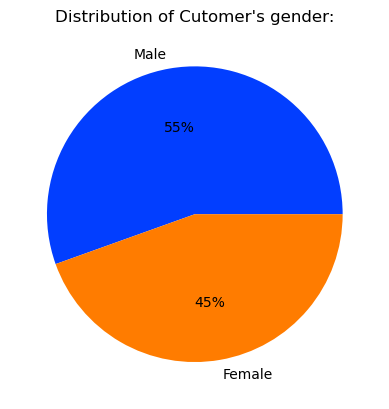


Distribution of cutomer's gender:

280273 Male
224933 Female


In [22]:
# distribution of customer's gender
make_piechart(df, 'gender')



> **There are more male customers in the company**



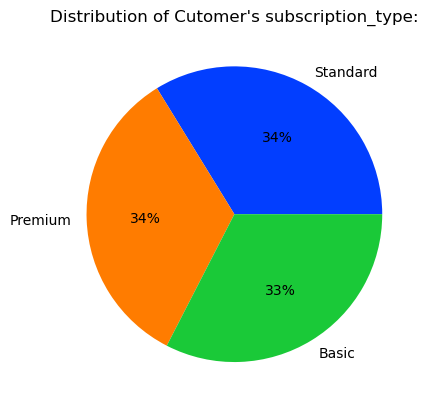


Distribution of cutomer's subscription_type:

170630 Standard
170099 Premium
164477 Basic


In [23]:
# distribution of customer's subscription_type
make_piechart(df, 'subscription_type')



> **Each subscription type (Standard, Premium, Basic) has a similar number of customers**



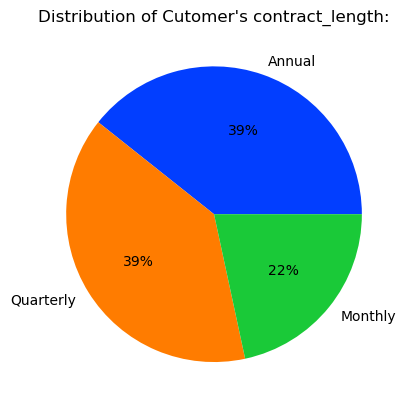


Distribution of cutomer's contract_length:

198608 Annual
197364 Quarterly
109234 Monthly


In [24]:
# distribution of customer's contract_length
make_piechart(df, 'contract_length')



> **Customers mostly go for either annual or quarterly contracts, with monthly contracts being the least favored option**



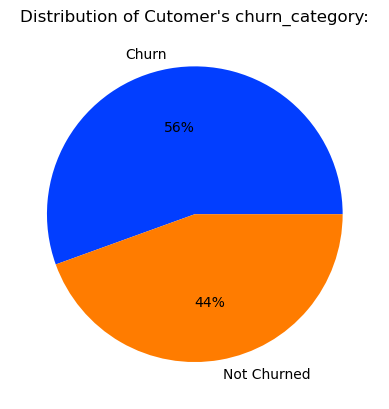


Distribution of cutomer's churn_category:

280492 Churn
224714 Not Churned


In [25]:
# disttribution of customer's churn category
churn_df = df.copy()
churn_df['churn_category'] = ['Churn' if x == 1.0 else 'Not Churned' for x in df['churn']]
make_piechart(churn_df, 'churn_category')



> **The dataset contains more entries of churned customers**



#### Discrete Features

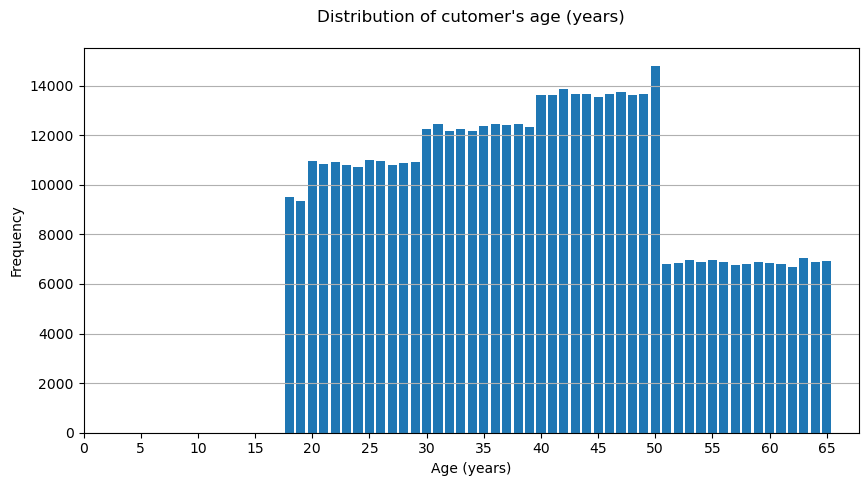


Distribution of cutomer's age (years): 

Median: 40.00 years
Minimum: 18 years
Maximum: 65 years



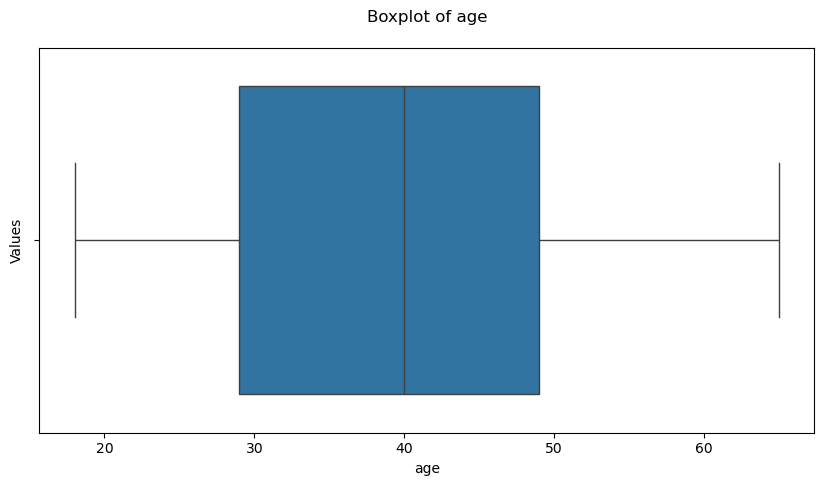

In [26]:
# bar plot and box plot of customer's age
make_barplot(df, 'age', custom_ticks=np.arange(0, 66, 5), additional=' (years)', unit='years')
make_boxplot(df, 'age')



> **Most customers are aged 40-50 with age 50 being the most common. There's very low number of customers of age 51 and above**



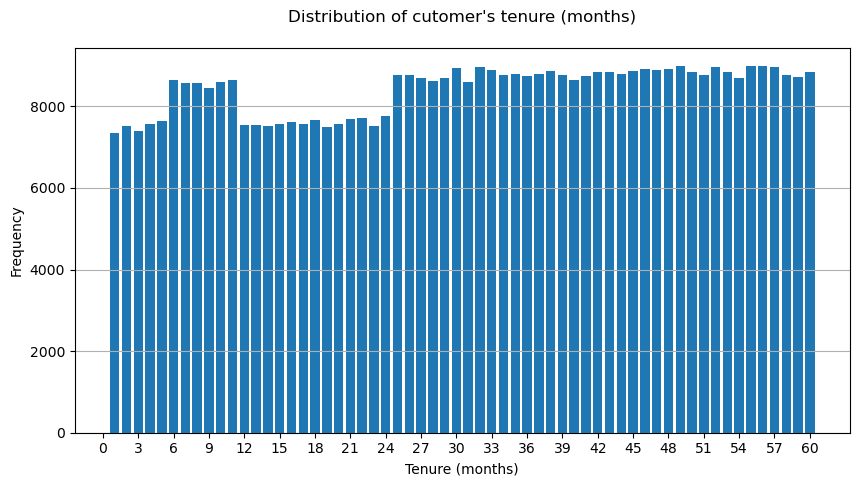


Distribution of cutomer's tenure (months): 

Median: 32.00 months
Minimum: 1 months
Maximum: 60 months



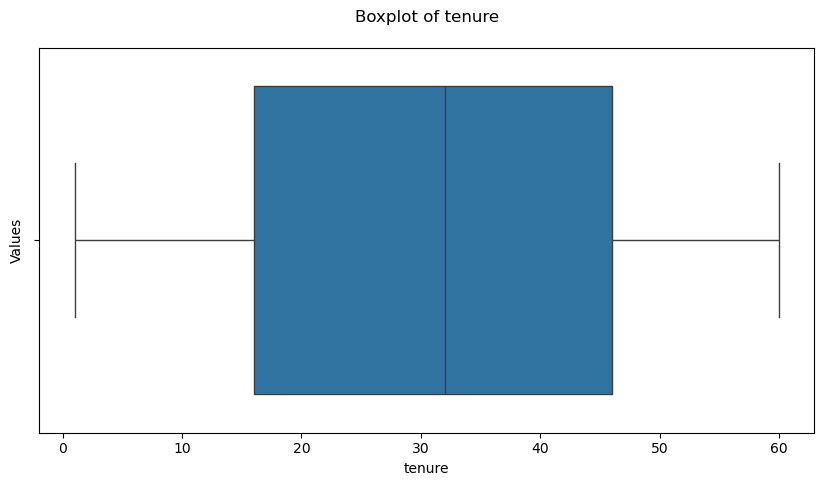

In [27]:
# bar plot and box plot of customer's tenure
make_barplot(df, 'tenure', custom_ticks=np.arange(0, 61, 3), additional=' (months)', unit='months')
make_boxplot(df, 'tenure')



> **Customers tend to have longer tenures with customer departures being more common during the 1-5 month and 12-24 month tenure periods**



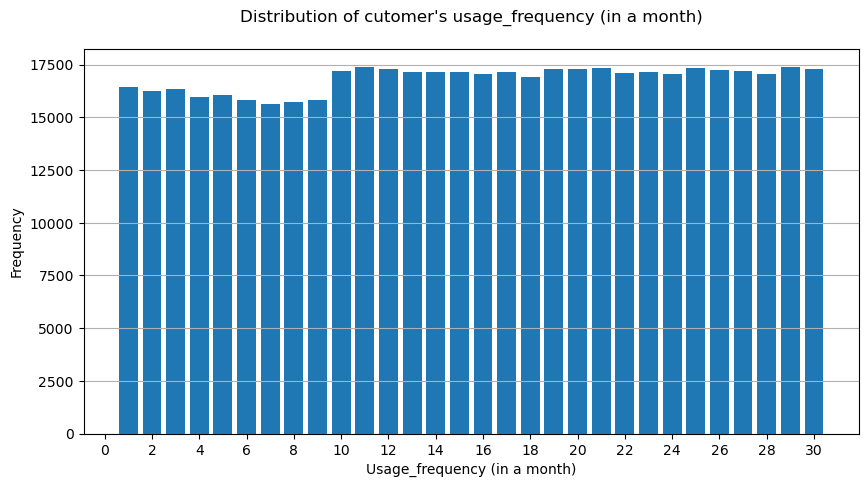


Distribution of cutomer's usage_frequency (in a month): 

Median: 16.00 times
Minimum: 1 times
Maximum: 30 times



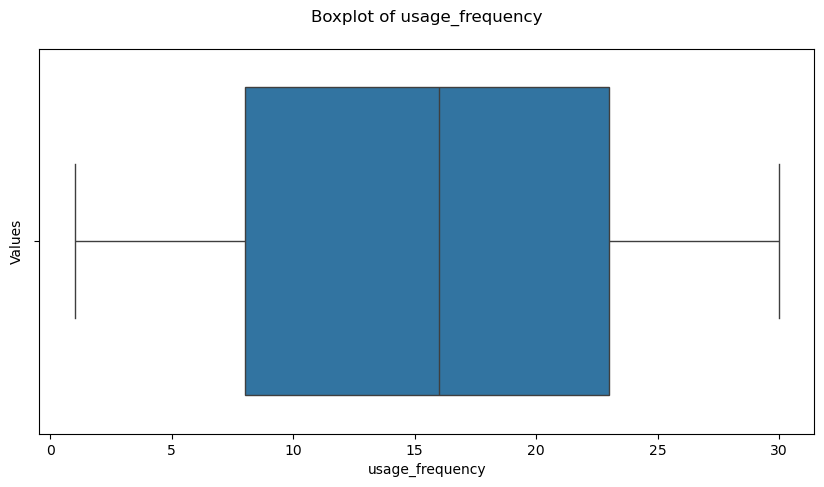

In [28]:
# bar plot and box plot of customer's usage_frequency
make_barplot(df, 'usage_frequency', custom_ticks=np.arange(0, 31, 2), unit='times', additional=' (in a month)')
make_boxplot(df, 'usage_frequency')



> **On average, customers tend to use company's services 16 times in a month, with a large variability in individual usage frequency suggesting diverse service consumption habits**



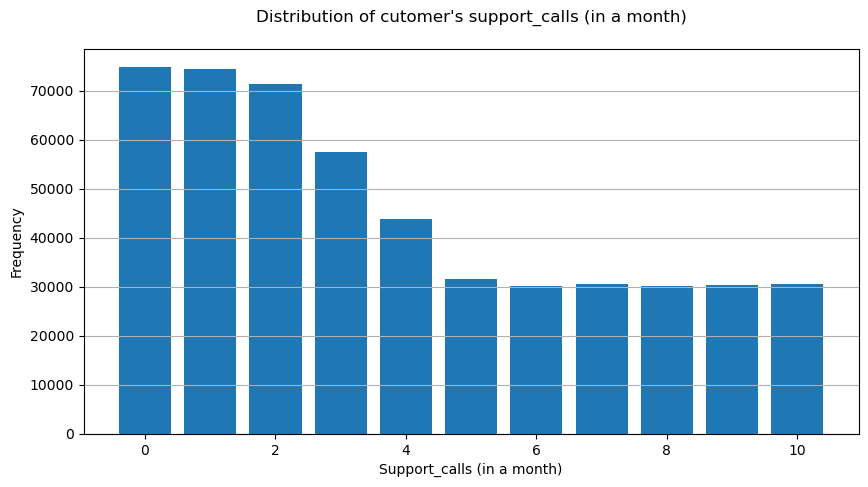


Distribution of cutomer's support_calls (in a month): 

Median: 3.00 calls
Minimum: 0 calls
Maximum: 10 calls



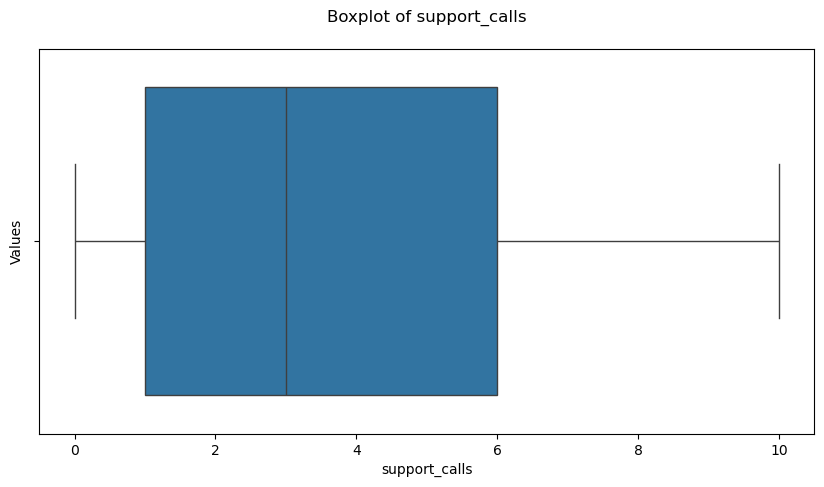

In [29]:
# bar plot and box plot of customer's support_calls
make_barplot(df, 'support_calls', unit='calls', additional=' (in a month)')
make_boxplot(df, 'support_calls')



> **On average, customers tend to make 3 support calls in a month. Customers tend to make 1 or 2 support calls per month, with the most make no support calls at all**



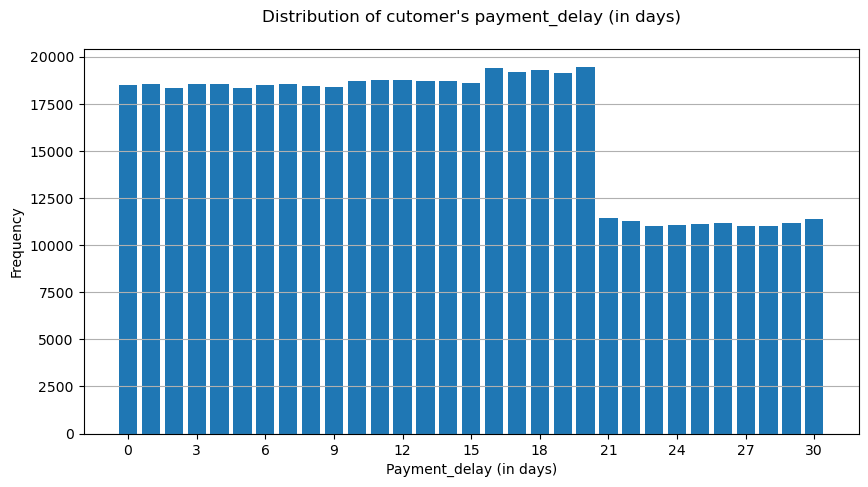


Distribution of cutomer's payment_delay (in days): 

Median: 13.00 days
Minimum: 0 days
Maximum: 30 days



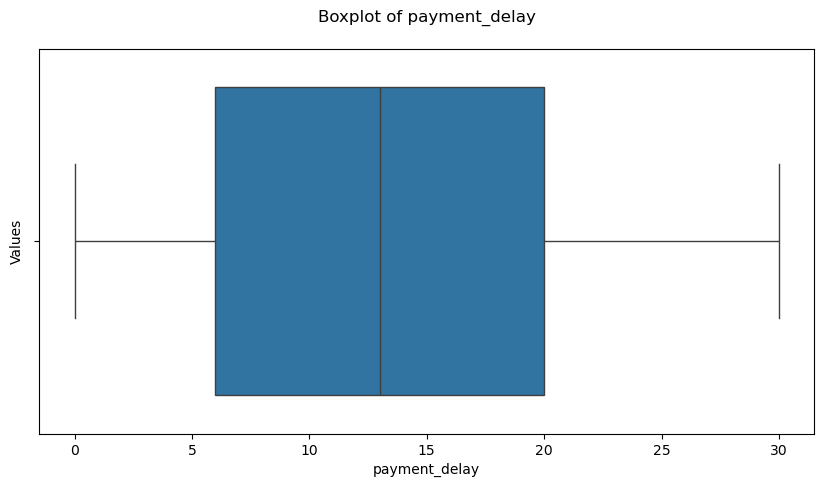

In [30]:
# bar plot and box plot of customer's payment_delay
make_barplot(df, 'payment_delay', custom_ticks=np.arange(0, 32, 3), unit='days', additional=' (in days)')
make_boxplot(df, 'payment_delay')



> **On average, customers tend to delay their payments by 13 days, with a large variability in individual payment delay durations suggesting unpreferable diverse payment habits. Most customers pay within 20 days**



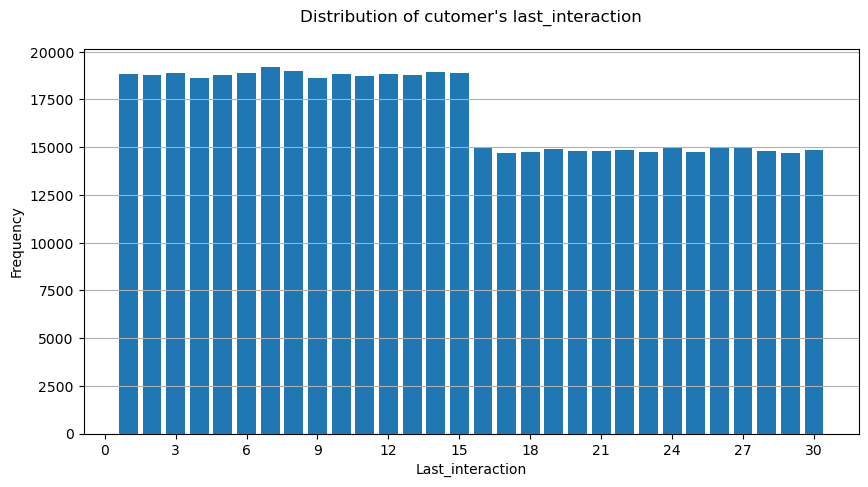


Distribution of cutomer's last_interaction: 

Median: 14.00 days
Minimum: 1 days
Maximum: 30 days



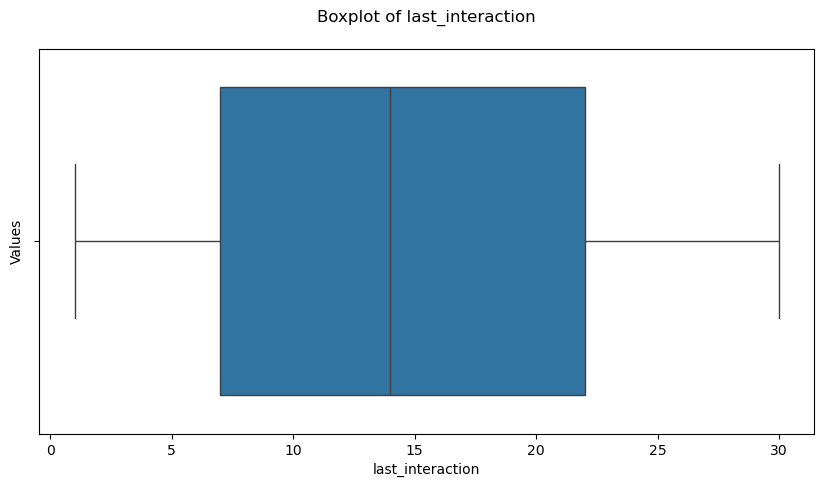

In [31]:
# bar plot and box plot of customer's last_interaction
make_barplot(df, 'last_interaction', custom_ticks=np.arange(0, 32, 3), unit='days', additional='')
make_boxplot(df, 'last_interaction')



> **Most customers tend to have 15 or less last interaction with average around 14 days**



#### Continuous Features

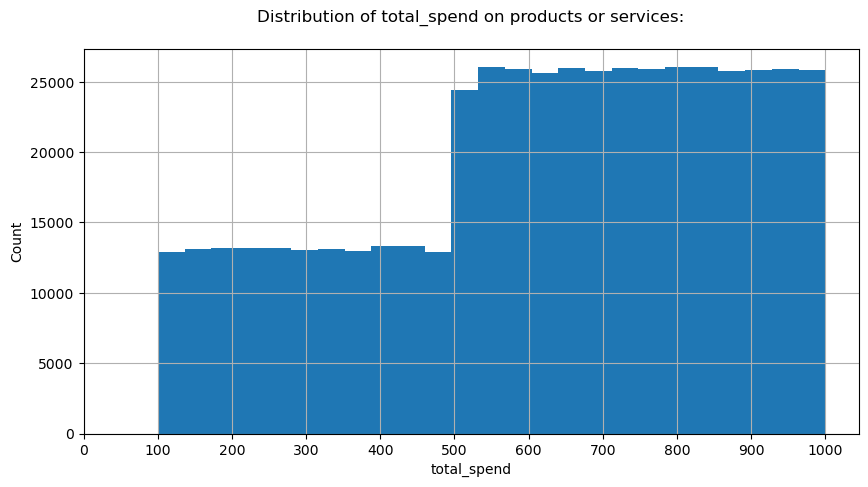


Distribution of total_spend on products or services:

Median: 648.90 USD
Minimum: 100.0 USD
Maximum: 1000.0 USD



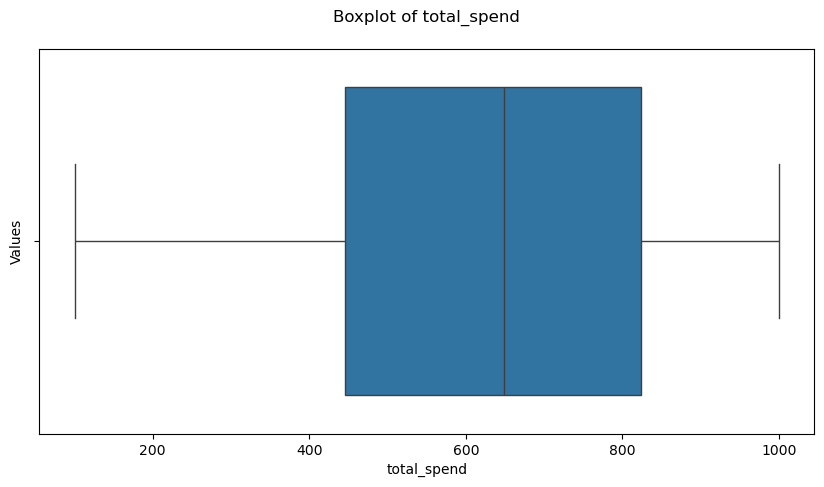

In [32]:
# histogram and box plot of customer's total_spend
make_histogram(df, 'total_spend', bins=25, custom_ticks=np.arange(0, 1001, 100), unit='USD', additional=" on products or services")
make_boxplot(df, 'total_spend')



> **On average customer tend to send around 631.62 USD, with a large variability on customer spending. Most customers tend spend more than 500 USD**

> **If we look at the histogram we can clearly see the division between customers who spend more and less is around 500. We can use this to divide customers into high value customers (total speding above 500) and low value customers (total speding below 500)**



### Multivariate Analysis

#### Do gender and churn rate have any relationship?

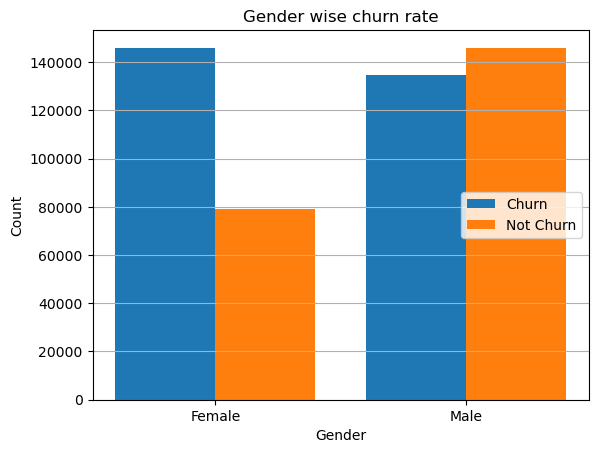

In [33]:
gender_churn = df.groupby(['gender', 'churn']).size().unstack()

X = list(gender_churn.index)
churn_0 = list(gender_churn.iloc[:, 0])
churn_1 = list(gender_churn.iloc[:, 1])

X_axis = np.arange(len(X))

plt.bar(X_axis-0.2, churn_1, 0.4, label = 'Churn')
plt.bar(X_axis+0.2, churn_0, 0.4, label = 'Not Churn')

plt.xticks(X_axis, X)
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title("Gender wise churn rate")
plt.legend(loc='center right')
plt.grid(axis='y')
plt.show()

> Yes, gender and churn rate have relationship.
> 
> Female customers exhibit a slightly higher churn rate compared to male customers. Active male customers (non-churned) is nearly double that of female customers.

#### Are there any noticeable trends in payment delays among customers who churned?

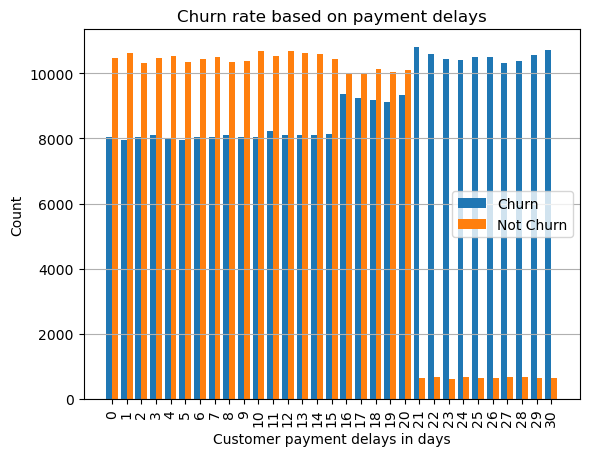

In [34]:
filtered = df.groupby(['payment_delay', 'churn']).size().unstack()

X = list(filtered.index)
churn_0 = list(filtered.iloc[:, 0])
churn_1 = list(filtered.iloc[:, 1])

X_axis = np.arange(len(X))

plt.bar(X_axis - 0.2, churn_1, 0.4, label = 'Churn')
plt.bar(X_axis + 0.2, churn_0, 0.4, label = 'Not Churn')

plt.xticks(X_axis, X, rotation=90)
plt.xlabel("Customer payment delays in days")
plt.ylabel('Count')
plt.title("Churn rate based on payment delays")
plt.legend(loc='center right')
plt.grid(axis='y')
plt.show()

> Customers who are not churned tend to have higher payment delay days as compared with churned customers till day 20, after which churned customers have payment delays just over 10 times than that of not churned customers.

#### What is the distribution of usage frequency for churned vs. non-churned customers?

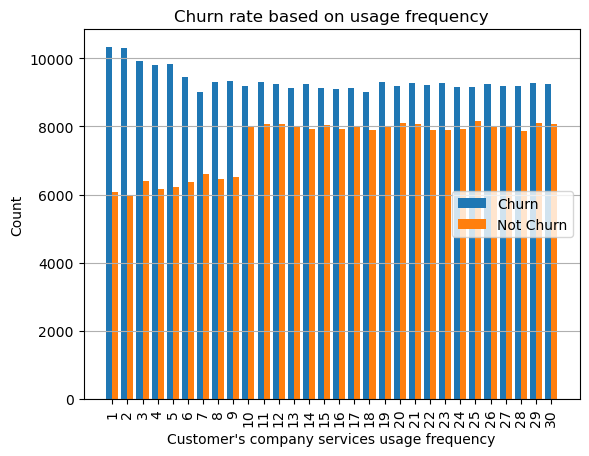

In [35]:
filtered = df.groupby(['usage_frequency', 'churn']).size().unstack()

X = list(filtered.index)
churn_0 = list(filtered.iloc[:, 0])
churn_1 = list(filtered.iloc[:, 1])

X_axis = np.arange(len(X))

plt.bar(X_axis - 0.2, churn_1, 0.4, label = 'Churn')
plt.bar(X_axis + 0.2, churn_0, 0.4, label = 'Not Churn')

plt.xticks(X_axis, X, rotation=90)
plt.xlabel("Customer's company services usage frequency")
plt.ylabel('Count')
plt.title("Churn rate based on usage frequency")
plt.legend(loc='center right')
plt.grid(axis='y')
plt.show()

> Churned customer tend to use company's services significantly more than customers who are not churned.

#### Are customers with longer tenures less likely to churn?

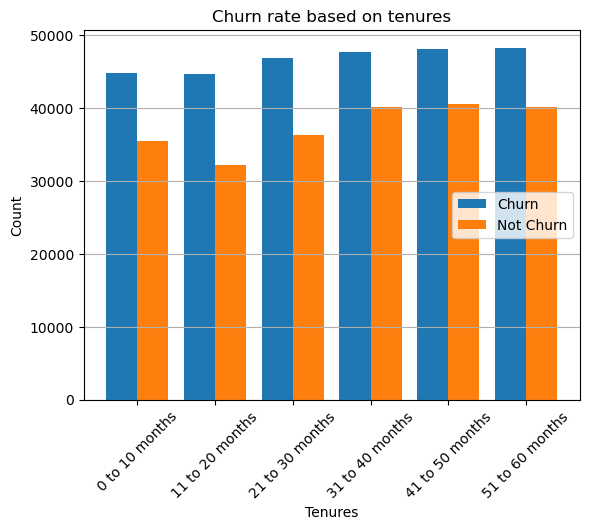

In [36]:
def categorize_age(age):
    if 0 <= age <= 10:
        return '0 to 10 months'
    elif 11 <= age <= 20:
        return '11 to 20 months'
    elif 21 <= age <= 30:
        return '21 to 30 months'
    elif 31 <= age <= 40:
        return '31 to 40 months'
    elif 41 <= age <= 50:
        return '41 to 50 months'
    elif 51 <= age <= 60:
        return '51 to 60 months'
    else:
        pass # For nan values

filtered = df.copy()
filtered['tenure_segmentation'] = df['tenure'].apply(categorize_age)
filtered = filtered.groupby(['tenure_segmentation', 'churn']).size().unstack()

X = list(filtered.index)
churn_0 = list(filtered.iloc[:, 0])
churn_1 = list(filtered.iloc[:, 1])

X_axis = np.arange(len(X))

plt.bar(X_axis - 0.2, churn_1, 0.4, label = 'Churn')
plt.bar(X_axis + 0.2, churn_0, 0.4, label = 'Not Churn')

plt.xticks(X_axis, X, rotation=45)
plt.xlabel('Tenures')
plt.ylabel('Count')
plt.title("Churn rate based on tenures")
plt.legend(loc='center right')
plt.grid(axis='y')
plt.show()

> No, customers with longer tenures are more likely to churn.

#### Do customers with more support calls tend to churn more?

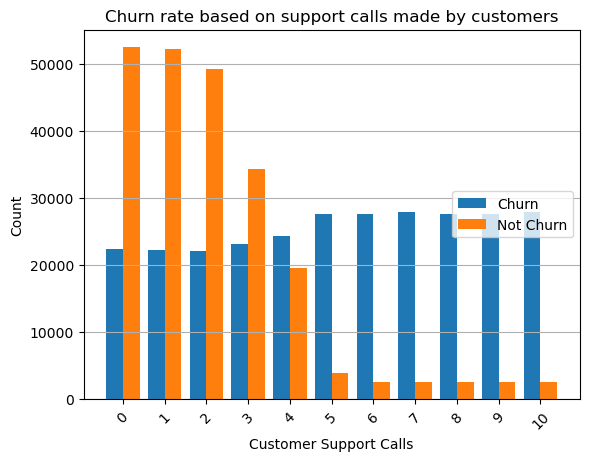

In [37]:
filtered = df.groupby(['support_calls', 'churn']).size().unstack()

X = list(filtered.index)
churn_0 = list(filtered.iloc[:, 0])
churn_1 = list(filtered.iloc[:, 1])

X_axis = np.arange(len(X))

plt.bar(X_axis - 0.2, churn_1, 0.4, label = 'Churn')
plt.bar(X_axis + 0.2, churn_0, 0.4, label = 'Not Churn')

plt.xticks(X_axis, X, rotation=45)
plt.xlabel('Customer Support Calls')
plt.ylabel('Count')
plt.title("Churn rate based on support calls made by customers")
plt.legend(loc='center right')
plt.grid(axis='y')
plt.show()

> Yes, customers with more support calls tend to churn more.
>
> On the contrary, customers who are not churned tend to make much more 0 to 3 customer support calls than churned customers, after which churned customers make significantly more calls.

#### Does the subscription type influence the churn rate?

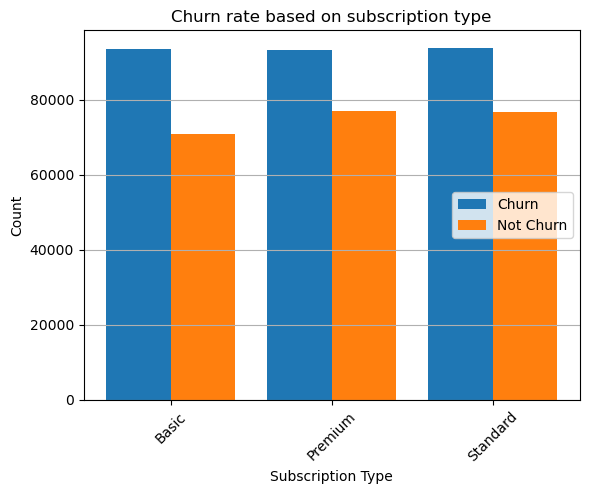

In [38]:
filtered = df.groupby(['subscription_type', 'churn']).size().unstack()

X = list(filtered.index)
churn_0 = list(filtered.iloc[:, 0])
churn_1 = list(filtered.iloc[:, 1])

X_axis = np.arange(len(X))

plt.bar(X_axis - 0.2, churn_1, 0.4, label = 'Churn')
plt.bar(X_axis + 0.2, churn_0, 0.4, label = 'Not Churn')

plt.xticks(X_axis, X, rotation=45)
plt.xlabel('Subscription Type')
plt.ylabel('Count')
plt.title("Churn rate based on subscription type")
plt.legend(loc='center right')
plt.grid(axis='y')
plt.show()

> No, the subscription type does not influence customer churn rate.
>
> Customers who are not churned tend to choose premium or standard subscription type slightly more than basic subscription.

#### Is there a pattern in contract length for customers who churned?

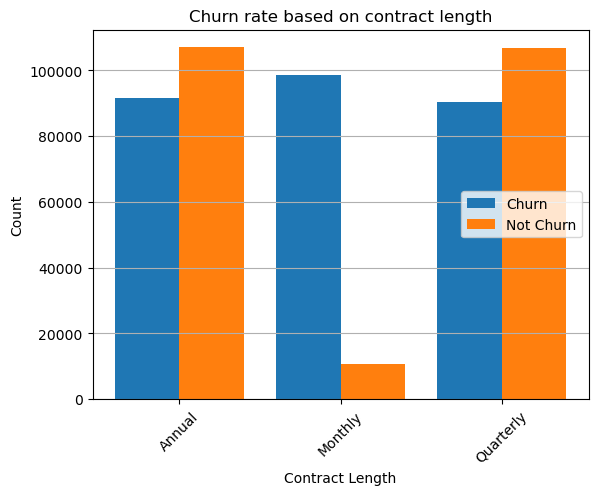

In [39]:
filtered = df.groupby(['contract_length', 'churn']).size().unstack()

X = list(filtered.index)
churn_0 = list(filtered.iloc[:, 0])
churn_1 = list(filtered.iloc[:, 1])

X_axis = np.arange(len(X))

plt.bar(X_axis - 0.2, churn_1, 0.4, label = 'Churn')
plt.bar(X_axis + 0.2, churn_0, 0.4, label = 'Not Churn')

plt.xticks(X_axis, X, rotation=45)
plt.xlabel('Contract Length')
plt.ylabel('Count')
plt.title("Churn rate based on contract length")
plt.legend(loc='center right')
plt.grid(axis='y')
plt.show()

> Customers with quarterly contract lengths have the lowest churn rate, while those with monthly contract lengths exhibit the highest churn rate. Conversely, customers who do not churn overwhelmingly prefer annual and quarterly contracts over monthly contracts.

#### Is there a correlation between total spend and churn rate?

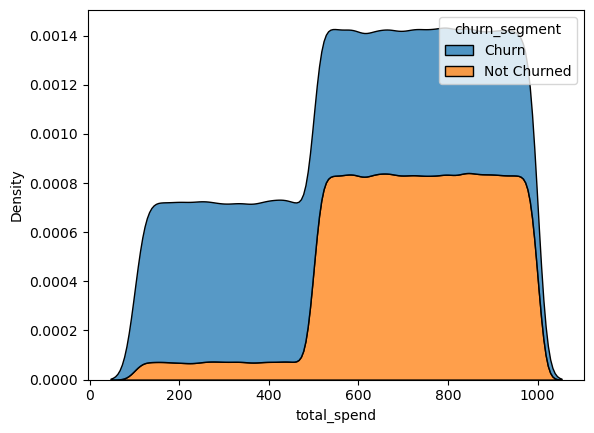

In [40]:
filtered = df.copy()
filtered['churn_segment'] = ['Churn' if x == 1.0 else 'Not Churned' for x in df['churn']]

sn.kdeplot(data=filtered, x="total_spend", hue="churn_segment", multiple="stack")
plt.show()

> Customers who churn tends to spend significantly more money than those who don't.
>
>Both churn and not churned customers share common total spending distribution / total spending behavior.

In [41]:
df.head()

,age,gender,tenure,usage_frequency,support_calls,payment_delay,subscription_type,contract_length,total_spend,last_interaction,churn
0,22,Female,25,14,4,27,Basic,Monthly,598.0,9,1
1,41,Female,28,28,7,13,Standard,Monthly,584.0,20,0
2,47,Male,27,10,2,29,Premium,Annual,757.0,21,0
3,35,Male,9,12,5,17,Premium,Quarterly,232.0,18,0
4,53,Female,58,24,9,2,Standard,Annual,533.0,18,0




#### ==> adding new features for multivariate analysis



In [42]:
# Create a copy of the original DataFrame
df_analysis = df.copy()

# 1. Total Spend per Month
df_analysis['total_spend_per_month'] = df_analysis['total_spend'] / df_analysis['tenure']

# 2. Average Interaction Time (using Last Interaction as a proxy)
avg_support_call_duration = 10  # in minutes
df_analysis['avg_interaction_time'] = (df_analysis['support_calls'] * avg_support_call_duration) / df_analysis['tenure']



In [43]:
# 3. Tenure & Subscription Type Interaction (using pd.get_dummies and interaction terms)
df_analysis['subscription_type'] = df_analysis['subscription_type'].str.strip()
dummies = pd.get_dummies(df_analysis['subscription_type'], prefix='sub_type', dtype= int)
final_df = pd.concat([df_analysis, dummies], axis=1)
final_df['tenure_sub_basic'] = final_df['tenure'] * final_df['sub_type_Basic']
final_df['tenure_sub_premium'] = final_df['tenure'] * final_df['sub_type_Premium']
final_df['tenure_sub_standard'] = final_df['tenure'] * final_df['sub_type_Standard']
final_df['tenure_sub_basic'] = final_df['tenure_sub_basic'].astype(int)
final_df['tenure_sub_premium'] = final_df['tenure_sub_premium'].astype(int)
final_df['tenure_sub_standard'] = final_df['tenure_sub_standard'].astype(int)

In [44]:
final_df.head()

,age,gender,tenure,usage_frequency,support_calls,payment_delay,subscription_type,contract_length,total_spend,last_interaction,churn,total_spend_per_month,avg_interaction_time,sub_type_Basic,sub_type_Premium,sub_type_Standard,tenure_sub_basic,tenure_sub_premium,tenure_sub_standard
0,22,Female,25,14,4,27,Basic,Monthly,598.0,9,1,23.920000,1.600000,1,0,0,25,0,0
1,41,Female,28,28,7,13,Standard,Monthly,584.0,20,0,20.857143,2.500000,0,0,1,0,0,28
2,47,Male,27,10,2,29,Premium,Annual,757.0,21,0,28.037037,0.740741,0,1,0,0,27,0
3,35,Male,9,12,5,17,Premium,Quarterly,232.0,18,0,25.777778,5.555556,0,1,0,0,9,0
4,53,Female,58,24,9,2,Standard,Annual,533.0,18,0,9.189655,1.551724,0,0,1,0,0,58


#### Does spending behavior (total spend per month) influence churn rate?

In [45]:
final_df.head()

,age,gender,tenure,usage_frequency,support_calls,payment_delay,subscription_type,contract_length,total_spend,last_interaction,churn,total_spend_per_month,avg_interaction_time,sub_type_Basic,sub_type_Premium,sub_type_Standard,tenure_sub_basic,tenure_sub_premium,tenure_sub_standard
0,22,Female,25,14,4,27,Basic,Monthly,598.0,9,1,23.920000,1.600000,1,0,0,25,0,0
1,41,Female,28,28,7,13,Standard,Monthly,584.0,20,0,20.857143,2.500000,0,0,1,0,0,28
2,47,Male,27,10,2,29,Premium,Annual,757.0,21,0,28.037037,0.740741,0,1,0,0,27,0
3,35,Male,9,12,5,17,Premium,Quarterly,232.0,18,0,25.777778,5.555556,0,1,0,0,9,0
4,53,Female,58,24,9,2,Standard,Annual,533.0,18,0,9.189655,1.551724,0,0,1,0,0,58


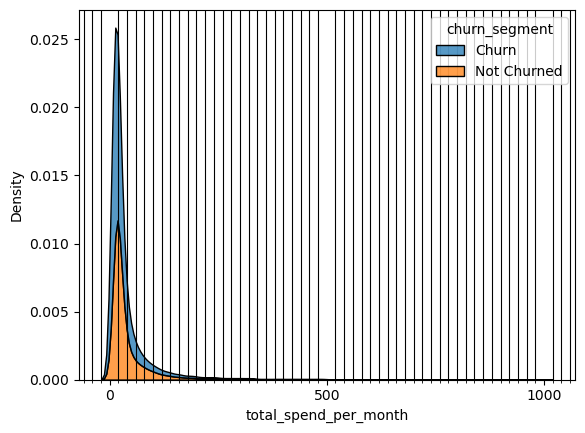

In [46]:
# kdeplot
filtered = final_df.copy()
filtered['churn_segment'] = ['Churn' if x == 1.0 else 'Not Churned' for x in final_df['churn']]

major_locator = MultipleLocator(500)
minor_locator = MultipleLocator(20)
plt.gca().xaxis.set_major_locator(major_locator)
plt.gca().xaxis.set_minor_locator(minor_locator)
plt.grid(which='minor', color='black')
sn.kdeplot(data=filtered, x="total_spend_per_month", hue="churn_segment", multiple="stack")
plt.show()

> The overlapping areas indicate that there are customers with similar spending patterns in both groups.

> The blue curve (churn) has a higher peak at lower spending levels, suggesting that customers with lower spending are more likely to churn.
>
> The orange curve (not churned) has a higher peak at higher spending levels, suggesting that customers with higher spending are less likely to churn.

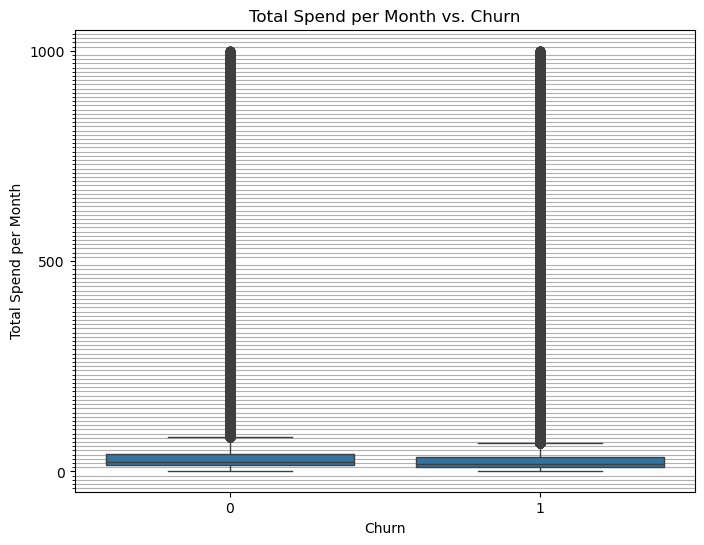

In [47]:
plt.figure(figsize=(8, 6))
sn.boxplot(data=df_analysis, x='churn', y='total_spend_per_month')
plt.title('Total Spend per Month vs. Churn')
plt.xlabel('Churn')
plt.ylabel('Total Spend per Month')
major_locator = MultipleLocator(500)
minor_locator = MultipleLocator(10)
plt.gca().yaxis.set_major_locator(major_locator)
plt.gca().yaxis.set_minor_locator(minor_locator)
plt.grid(which='minor')
plt.show()

> While the median spend is similar for both groups, the presence of outliers in the churned group might suggest that some customers with very high or very low spending are more likely to churn.

#### Is there a relationship between last interaction time and customer churn?

In [49]:
final_df.head()

,age,gender,tenure,usage_frequency,support_calls,payment_delay,subscription_type,contract_length,total_spend,last_interaction,churn,total_spend_per_month,avg_interaction_time,sub_type_Basic,sub_type_Premium,sub_type_Standard,tenure_sub_basic,tenure_sub_premium,tenure_sub_standard
0,22,Female,25,14,4,27,Basic,Monthly,598.0,9,1,23.920000,1.600000,1,0,0,25,0,0
1,41,Female,28,28,7,13,Standard,Monthly,584.0,20,0,20.857143,2.500000,0,0,1,0,0,28
2,47,Male,27,10,2,29,Premium,Annual,757.0,21,0,28.037037,0.740741,0,1,0,0,27,0
3,35,Male,9,12,5,17,Premium,Quarterly,232.0,18,0,25.777778,5.555556,0,1,0,0,9,0
4,53,Female,58,24,9,2,Standard,Annual,533.0,18,0,9.189655,1.551724,0,0,1,0,0,58


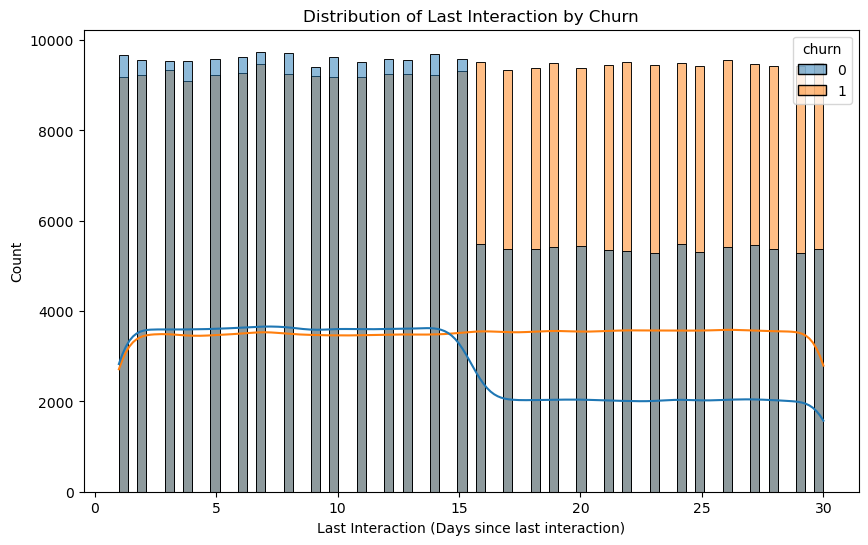

In [50]:
# Histogram
plt.figure(figsize=(10, 6))
sn.histplot(data=final_df, x='last_interaction', hue='churn', kde=True)
plt.title('Distribution of Last Interaction by Churn')
plt.xlabel('Last Interaction (Days since last interaction)')
plt.ylabel('Count')
plt.show()

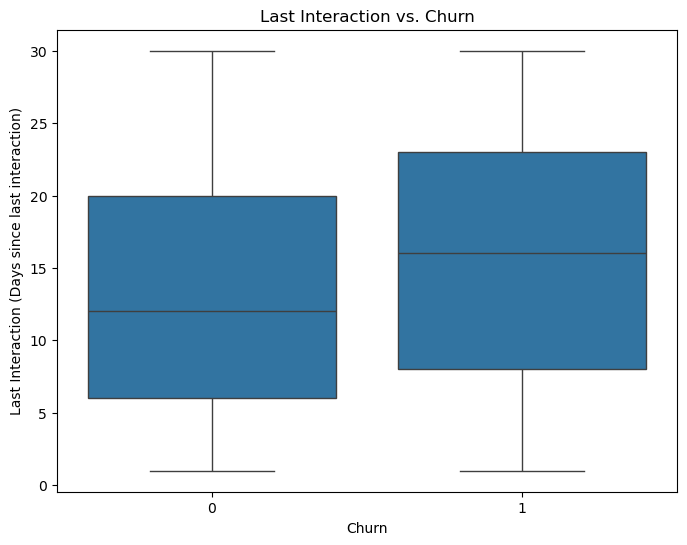

In [51]:
# Box Plot
plt.figure(figsize=(8, 6))
sn.boxplot(data=final_df, x='churn', y='last_interaction')
plt.title('Last Interaction vs. Churn')
plt.xlabel('Churn')
plt.ylabel('Last Interaction (Days since last interaction)')
plt.show()

>  Customers who churned may have had fewer recent interactions with the company. This could indicate a decline in engagement or satisfaction leading to churn.

#### How does the combination of tenure and subscription type impact churn likelihood?

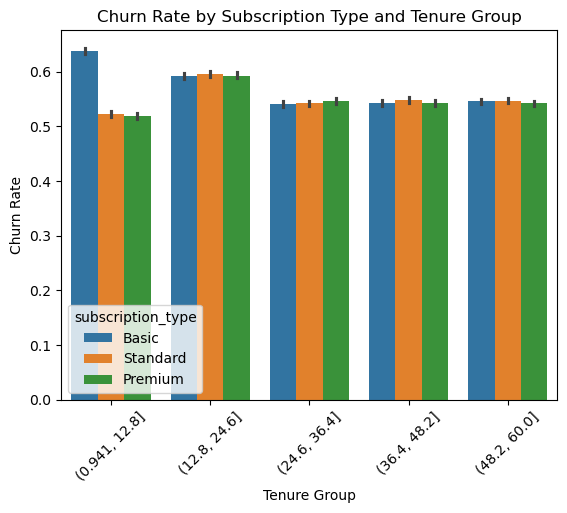

In [53]:
final_df['tenure_group'] = pd.cut(final_df['tenure'], bins=5)
sn.barplot(data=final_df, x='tenure_group', y='churn', hue='subscription_type',
hue_order=['Basic', 'Standard', 'Premium'])
plt.title('Churn Rate by Subscription Type and Tenure Group')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate')
plt.xticks(rotation=45)
plt.show()

> These observations suggest that customers with Basic subscriptions are more likely to churn in the early stages of their tenure. Retention efforts might be particularly important for this customer segment.

## Correlation

### Independent Features Correlation

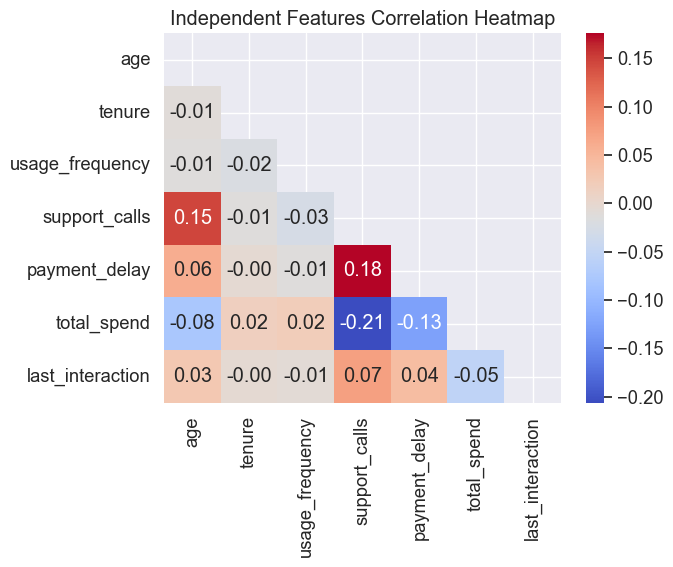

In [54]:
independent_features_df = df.select_dtypes(include=['number']).copy().drop(columns=['churn'])

corr_matrix = independent_features_df.corr()

# Creating a mask to hide the upper triangle of the heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# plt.figure(figsize=(10, 8))
sn.set(font_scale=1.2)
sn.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", mask=mask)
plt.title("Independent Features Correlation Heatmap")
plt.show()

### Inpedendent features correlation with prediction labels

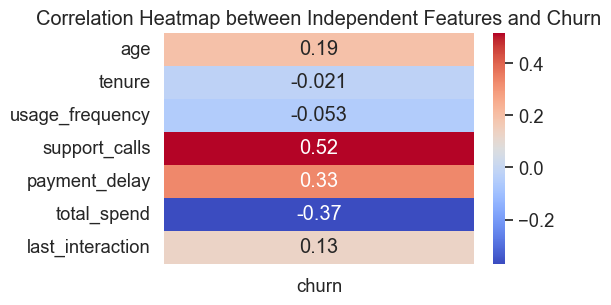

In [55]:
correlation_data = df.select_dtypes(include=['number']).corr().loc[:'last_interaction', 'churn']

# Create a heatmap
plt.figure(figsize=(5, 3))
sn.set(font_scale=1.2)
sn.heatmap(correlation_data.to_frame(), annot=True, cmap="coolwarm", cbar=True)

plt.title("Correlation Heatmap between Independent Features and Churn")
plt.show()

## Splitting the dataset

In [56]:
X= df.drop('churn', axis=1)
y= df['churn']

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Reset the index of the resulting DataFrames
X_train.reset_index(drop=True, inplace=True)
X_test.reset_index(drop=True, inplace=True)
y_train.reset_index(drop=True, inplace=True)
y_test.reset_index(drop=True, inplace=True)

In [58]:
X_train.head()

,age,gender,tenure,usage_frequency,support_calls,payment_delay,subscription_type,contract_length,total_spend,last_interaction
0,24,Male,4,22,3,9,Basic,Quarterly,982.00,28
1,39,Male,50,7,0,10,Standard,Annual,581.00,11
2,63,Female,28,27,9,20,Standard,Quarterly,645.00,15
3,21,Female,5,16,6,2,Premium,Annual,289.00,7
4,55,Male,4,20,1,18,Premium,Annual,984.62,18


In [59]:
X_test.head()

,age,gender,tenure,usage_frequency,support_calls,payment_delay,subscription_type,contract_length,total_spend,last_interaction
0,60,Female,56,16,2,1,Standard,Annual,400.00,7
1,30,Male,37,27,1,16,Standard,Annual,585.19,2
2,26,Male,45,24,1,13,Premium,Quarterly,671.29,21
3,50,Male,10,21,4,11,Basic,Quarterly,538.00,9
4,35,Female,19,23,5,13,Standard,Annual,457.00,9


## Encoding categorical data

In [60]:
ohe= OneHotEncoder(sparse_output=False)
ohe.fit(X_train[['gender', 'subscription_type', 'contract_length']])

OneHotEncoder(sparse_output=False)

In [61]:
feature_names = ohe.get_feature_names_out(['gender', 'subscription_type', 'contract_length'])
feature_names

array(['gender_Female', 'gender_Male', 'subscription_type_Basic',
       'subscription_type_Premium', 'subscription_type_Standard',
       'contract_length_Annual', 'contract_length_Monthly',
       'contract_length_Quarterly'], dtype=object)

In [62]:
train_categorical_ohe_data = ohe.transform(X_train[['gender', 'subscription_type', 'contract_length']])
train_ohe_df = pd.DataFrame(train_categorical_ohe_data, columns=feature_names)

test_categorical_ohe_data = ohe.transform(X_test[['gender', 'subscription_type', 'contract_length']])
test_ohe_df = pd.DataFrame(test_categorical_ohe_data, columns=feature_names)

In [63]:
train_ohe_df.columns

Index(['gender_Female', 'gender_Male', 'subscription_type_Basic',
       'subscription_type_Premium', 'subscription_type_Standard',
       'contract_length_Annual', 'contract_length_Monthly',
       'contract_length_Quarterly'],
      dtype='object')

In [64]:
X_train = X_train.drop(columns=['gender', 'subscription_type', 'contract_length'])
X_test = X_test.drop(columns=['gender', 'subscription_type', 'contract_length'])

In [65]:
X_train.columns

Index(['age', 'tenure', 'usage_frequency', 'support_calls', 'payment_delay',
       'total_spend', 'last_interaction'],
      dtype='object')

In [66]:
X_train = pd.concat([X_train, train_ohe_df], axis=1)
X_test = pd.concat([X_test, test_ohe_df], axis=1)

In [67]:
X_train.head(3)

,age,tenure,usage_frequency,support_calls,payment_delay,total_spend,last_interaction,gender_Female,gender_Male,subscription_type_Basic,subscription_type_Premium,subscription_type_Standard,contract_length_Annual,contract_length_Monthly,contract_length_Quarterly
0,24,4,22,3,9,982.0,28,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
1,39,50,7,0,10,581.0,11,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
2,63,28,27,9,20,645.0,15,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


## PCA

In [68]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)


In [69]:
pca.explained_variance_ratio_

array([0.98872677, 0.00488151])

In [70]:
data = {
    'Feature_1': X_pca[:, 0],
    'Feature_2': X_pca[:, 1],
    'Target': y_train
}

pca_df = pd.DataFrame(data)
pca_df

,Feature_1,Feature_2,Target
0,-361.873076,27.713660,1
1,39.095425,-18.835247,0
2,-24.716327,3.910804,1
3,331.037565,25.653561,1
4,-364.351376,28.111434,1
...,...,...,...
404159,-340.739521,19.190762,1
404160,-81.111913,25.254602,0
404161,-301.720834,12.705679,1
404162,454.040186,-17.435128,1


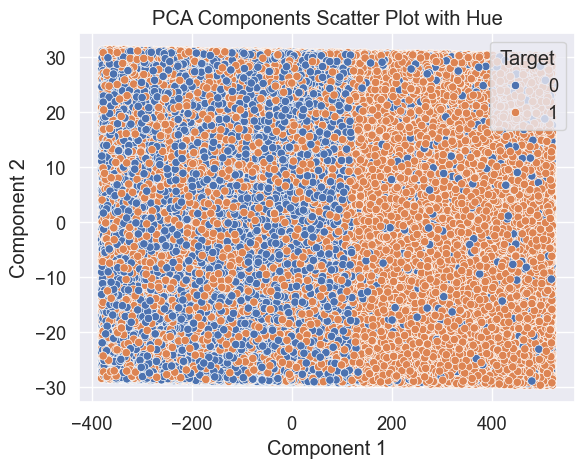

In [71]:
sn.scatterplot(data=pca_df, x='Feature_1', y='Feature_2', hue='Target')

plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.title('PCA Components Scatter Plot with Hue')
plt.legend(title='Target')
plt.show()

## Checking different models' accuracy

> **GridSearchCV is taking too much time to execute**

In [72]:

# model_params={
#     'decisiontree':{
#         'model': DecisionTreeClassifier(),
#         'params': {
#             'criterion':['gini', 'entropy']
#         }
#     },
#     'logistic_regression': {
#         'model': LogisticRegression(solver='liblinear', max_iter=100),
#         'params': {
#             'C':[1,5,10]
#         }
#     },
#     'random_forest':{
#         'model': RandomForestClassifier(),
#         'params': {
#             'n_estimators':[1,5,10]
#         }
#     }
# }

# scores=[]
# for model_name, mp in model_params.items():
#     rs=GridSearchCV(mp['model'], mp['params'], cv=5)
#     rs.fit(X_train, y_train)
#     scores.append({
#         'model': model_name,
#         'best_score': rs.best_score_,
#         'best_params': rs.best_params_
#     })

# model_performance_df= pd.DataFrame(scores, columns=['model', 'best_score', 'best_params'])
# model_performance_df

In [73]:
# model_params2={
#     'knn': {
#         'model': KNeighborsClassifier(),
#         'params': {
#             'n_neighbors':[1,5,10]
#         }
#     },
#     'gaussian':{
#         'model': GaussianNB(),
#         'params': {}
#     },
#     'multinomial':{
#         'model': MultinomialNB(),
#         'params': {}
#     }
# }

# scores2=[]
# for model_name, mp in model_params2.items():
#     rs=GridSearchCV(mp['model'], mp['params'], cv=5)
#     rs.fit(X_train, y_train)
#     scores2.append({
#         'model': model_name,
#         'best_score': rs.best_score_,
#         'best_params': rs.best_params_
#     })

# model_performance_df2= pd.DataFrame(scores2, columns=['model', 'best_score', 'best_params'])
# model_performance_df2

In [74]:
def print_evaluation_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)

    print(f"Accuracy: {accuracy:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print()
    
    conf_matrix = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix:")
    print(conf_matrix)
    print()

    class_report = classification_report(y_true, y_pred)
    print("Classification Report:")
    print(class_report)

In [75]:
def k_fold_cross_validation_with_metrics(classifier, X, y, k_folds=5):
    
    # Initializing stratified k-fold cross-validation
    stratified_kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

    # Lists to store the evaluation metrics for each fold
    accuracy_scores = []
    precision_scores = []
    recall_scores = []

    # Perform cross-validation
    for train_index, test_index in stratified_kf.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Fit the classifier on the training data
        classifier.fit(X_train, y_train)

        # Make predictions on the test data
        y_pred = classifier.predict(X_test)

        # Calculate evaluation metrics for this fold
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)

        # Append the metrics to their respective lists
        accuracy_scores.append(accuracy)
        precision_scores.append(precision)
        recall_scores.append(recall)

    # Calculate and print the mean of each metric across all folds
    mean_accuracy = np.mean(accuracy_scores)
    mean_precision = np.mean(precision_scores)
    mean_recall = np.mean(recall_scores)
    print("Mean Metrics Across Folds:")
    print(f"Mean Accuracy: {mean_accuracy:.2f}")
    print(f"Mean Precision: {mean_precision:.2f}")
    print(f"Mean Recall: {mean_recall:.2f}")


In [76]:
logReg = LogisticRegression(solver='liblinear', max_iter=100)

k_fold_cross_validation_with_metrics(logReg, X_train, y_train)

Mean Metrics Across Folds:
Mean Accuracy: 0.85
Mean Precision: 0.87
Mean Recall: 0.85


In [77]:
gnb = GaussianNB()

k_fold_cross_validation_with_metrics(gnb, X_train, y_train)

Mean Metrics Across Folds:
Mean Accuracy: 0.86
Mean Precision: 0.91
Mean Recall: 0.83


In [78]:
mnb = MultinomialNB()

k_fold_cross_validation_with_metrics(mnb, X_train, y_train)

Mean Metrics Across Folds:
Mean Accuracy: 0.74
Mean Precision: 0.81
Mean Recall: 0.70


In [79]:
knn_clsf = KNeighborsClassifier()

k_fold_cross_validation_with_metrics(knn_clsf, X_train, y_train)

Mean Metrics Across Folds:
Mean Accuracy: 0.84
Mean Precision: 0.89
Mean Recall: 0.83


In [80]:
decision_tree_clsf = DecisionTreeClassifier(random_state=42)

k_fold_cross_validation_with_metrics(decision_tree_clsf, X_train, y_train)

Mean Metrics Across Folds:
Mean Accuracy: 0.88
Mean Precision: 0.90
Mean Recall: 0.88


In [81]:
rf_clsf = RandomForestClassifier(random_state=42)

k_fold_cross_validation_with_metrics(rf_clsf, X_train, y_train)

Mean Metrics Across Folds:
Mean Accuracy: 0.93
Mean Precision: 0.90
Mean Recall: 1.00


In [82]:
xgb_clsf = xgb.XGBClassifier(random_state=42)

k_fold_cross_validation_with_metrics(xgb_clsf, X_train, y_train)

Mean Metrics Across Folds:
Mean Accuracy: 0.93
Mean Precision: 0.90
Mean Recall: 0.99


In [83]:
# fetching top 5 important features
importances = rf_clsf.feature_importances_
indices = np.argsort(importances[:5])[::-1]

for f in range(5):
    print(f"{f+1}. Feature {df.columns[indices[f]]}: {importances[indices[f]]}")

1. Feature usage_frequency: 0.2511086330346628
2. Feature support_calls: 0.14229465911447714
3. Feature age: 0.1295064232907196
4. Feature gender: 0.042777300372027906
5. Feature tenure: 0.03306115310014963


## Model Training and Testing 
### since Decision Trees, Random Forest & Xgboost all three have perfect score, so training our data on these models
### Focus will be on best recall.

### training

In [84]:
decision_tree_clsf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [85]:
rf_clsf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [86]:
xgb_clsf.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

### testing

In [87]:
y_pred = decision_tree_clsf.predict(X_test)
print_evaluation_metrics(y_test, y_pred)

Accuracy: 0.88
Precision: 0.90
Recall: 0.88

Confusion Matrix:
[[39746  5340]
 [ 6593 49363]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.88      0.87     45086
           1       0.90      0.88      0.89     55956

    accuracy                           0.88    101042
   macro avg       0.88      0.88      0.88    101042
weighted avg       0.88      0.88      0.88    101042



In [88]:
y_pred = rf_clsf.predict(X_test)
print_evaluation_metrics(y_test, y_pred)

Accuracy: 0.93
Precision: 0.90
Recall: 1.00

Confusion Matrix:
[[38685  6401]
 [  181 55775]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.86      0.92     45086
           1       0.90      1.00      0.94     55956

    accuracy                           0.93    101042
   macro avg       0.95      0.93      0.93    101042
weighted avg       0.94      0.93      0.93    101042



In [89]:
y_pred = xgb_clsf.predict(X_test)
print_evaluation_metrics(y_test, y_pred)

Accuracy: 0.93
Precision: 0.90
Recall: 0.99

Confusion Matrix:
[[38704  6382]
 [  309 55647]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.86      0.92     45086
           1       0.90      0.99      0.94     55956

    accuracy                           0.93    101042
   macro avg       0.94      0.93      0.93    101042
weighted avg       0.94      0.93      0.93    101042



# **For now Random Forest is the near perfect model for the problem**